# **"Sherlock": The Bayesian Detective Challenge**

### **The Scenario**
You are the lead AI architect for a predictive policing unit. Your system receives noisy evidence (data points) and must classify them into different "Events" (Classes). The system must **make decisions** based on distributions to minimize error.

You will use **Bayesian Decision Theory** to minimize risk and calculate the true probability of events.

### **Part 1: Conceptual Stress-Tests**

> **How to approach these questions:**
> * **Q1:** Consider the difference between **Maximum Likelihood (ML)** and **Maximum A Posteriori (MAP)**. What happens when your "Prior" belief is very strong?
>
> * **Q2:** Visualize the geometry of the Normal Distribution. What defines the shape of the decision boundary between two classes?

**Question 1: The "Naive" Detective**

Your system is trying to decide if an email is "Spam" ($\omega_1$) or "Not Spam" ($\omega_2$).
The likelihood of the email content appearing in Spam is **slightly** lower than in Not Spam: $P(x|\omega_1) < P(x|\omega_2)$.
However, you know for a fact that 99% of all emails received are Spam ($P(\omega_1) = 0.99$). 

If you use the **Bayesian Decision Rule**, what will the system decide?

**A)** It will classify as "Not Spam" because the evidence $x$ fits that class better.

**B)** It will likely classify as "Spam" because the **Prior** $P(\omega_1)$ dominates the decision, outweighing the weak likelihood evidence.

**C)** It is impossible to decide without the Evidence $P(x)$.

**D)** It will default to the class with the smaller variance.

**Answer:** **B)** It will likely classify as "Spam" because the **Prior** $P(\omega_1)$ dominates the decision, outweighing the weak likelihood evidence.

explanation: In Bayesian Decision Theory the posterior probability is calculated as $P(\omega_i|x) \propto P(x|\omega_i)P(\omega_i)$. Even though the likelihood $P(x|\omega_1)$ is slightly lower, the very high prior $P(\omega_1) = 0.99$ will dominate the posterior leading to a classification of "Spam".

**Question 2: The Shape of the Boundary**
*Topic: Simplifying Bayesian Decision Making*

You are classifying data into two classes, A and B. Both classes are distributed as **Multivariate Normal Distributions** ($\mathcal{N}$).
You discover that both classes have **identical Covariance Matrices** ($\Sigma_A = \Sigma_B = \Sigma$), though their means are different.

What is the shape of the optimal Bayesian Decision Boundary?

**A)** A Quadratic Surface (Second-order boundary).

**B)** A Hyper-plane (Linear).

**C)** An Ellipse wrapping around the mean of Class A.

**D)** It depends on the magnitude of the means.

**Answer:** 
**B)** A Hyper-plane (Linear).

explanation: When both classes have identical covariance matrices the quadratic terms in the discriminant functions cancel out resulting in a linear decision boundary. Thus the optimal Bayesian Decision Boundary is a hyper-plane separating the two classes.

### **Part 2: The Arithmetic of Belief**

> **How to approach Q3:** Use **Bayes Rule**. Remember that Posterior = (Likelihood × Prior) / Evidence.

**Question 3: The Disease Paradox**
*Topic: Problem 2 & Bayes Theorem *

A digital virus exists in 40% of servers ($P(\omega_{virus}) = 0.4$).
You have a detection tool that is:
* 60% accurate when the virus is present (True Positive: $P(+ | \omega_{virus}) = 0.6$)
* 10% likely to raise a false alarm when the virus is NOT present (False Positive: $P(+ | \omega_{clean}) = 0.1$)

If your tool alerts you (**Positive result**), what is the actual probability that the server has the virus?
**Calculate $P(\omega_{virus} | +)$. Show your steps.**

![WhatsApp Image 2026-02-05 at 18.06.50.jpeg](<attachment:WhatsApp Image 2026-02-05 at 18.06.50.jpeg>)
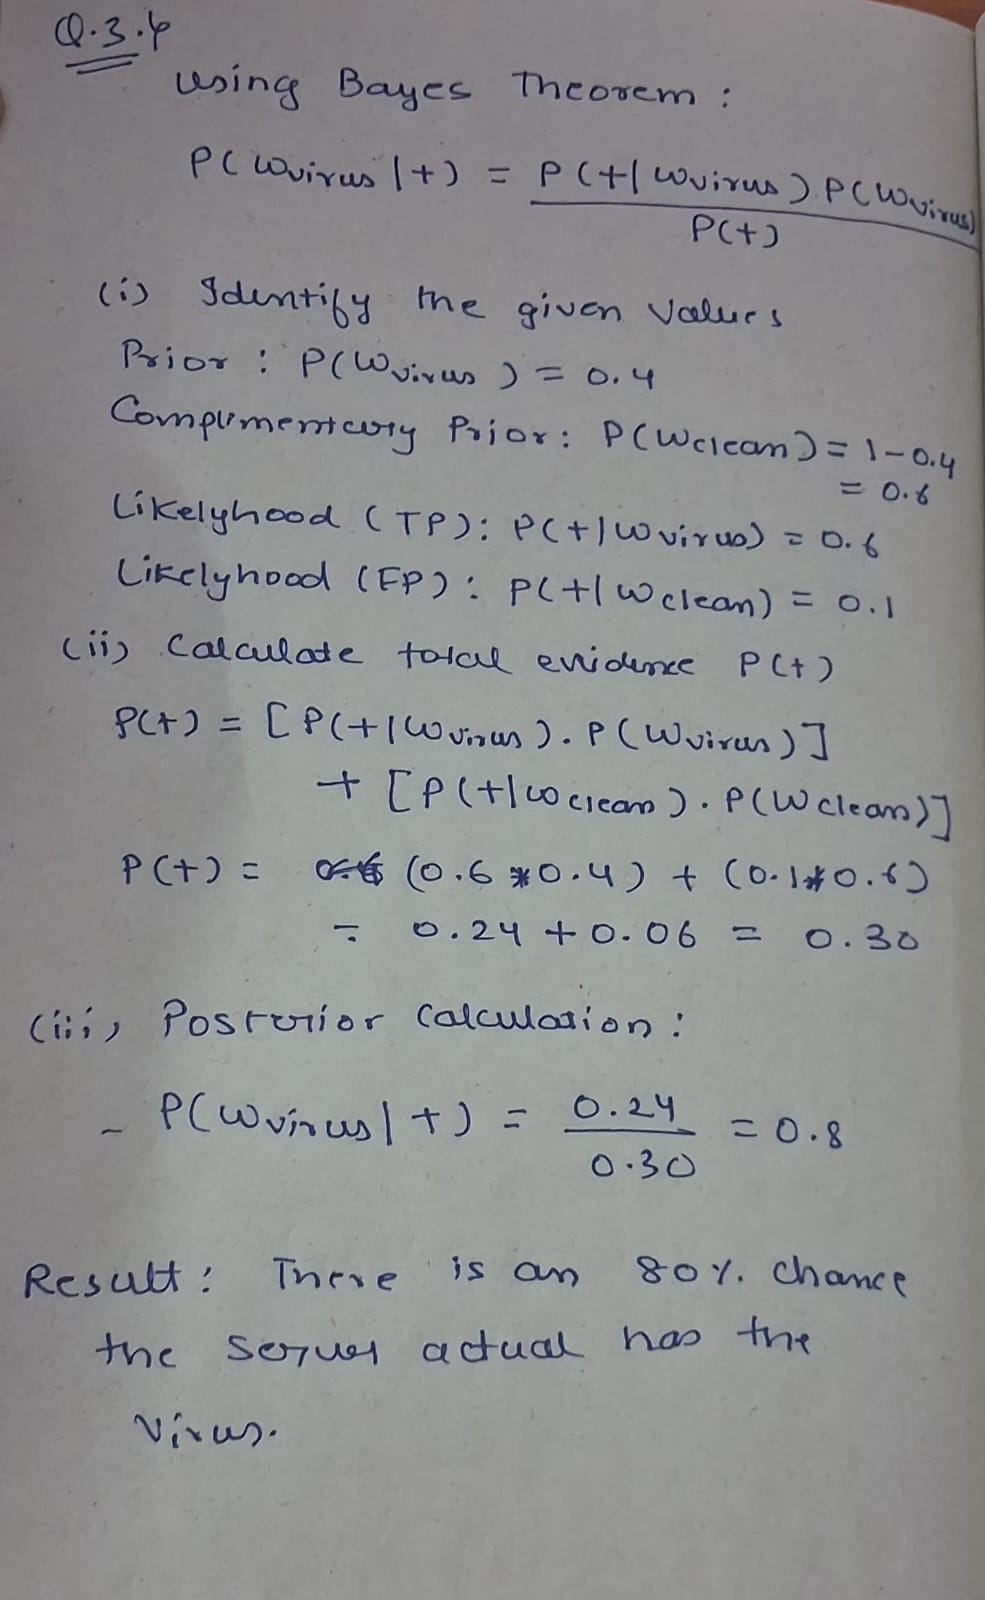

**Question 4: The "Streaming" Mean**
*Topic: Problem 5: Streaming Data*

In real-time AI, data arrives one piece at a time ("Streaming Data"). You cannot store all previous data points to calculate the Mean.
You have the current mean $\mu_{N}$ calculated from $N$ samples. A new sample $x_{N+1}$ arrives.

1.  Write the formula to update the mean $\mu_{N+1}$ using **only** $\mu_{N}$, $N$, and $x_{N+1}$ .
2.  If $\mu_{10} = 50$ (calculated from 10 samples) and the 11th sample is $x_{11} = 105$, what is the new mean $\mu_{11}$?

Answer: 
1. The formula to update the mean is:
$$\mu_{N+1} = \mu_N + \frac{x_{N+1} - \mu_N}{N+1}$$
2. Plugging in the values:
$$\mu_{11} = \frac{10 \cdot 50 + 105}{10 + 1} = \frac{500 + 105}{11} = \frac{605}{11} \approx 55$$
Thus, the new mean $\mu_{11}$ is approximately 55.



## **Part 3: Coding Challenge — Building the Bayesian Classifier**

In this section, you will implement a **Gaussian Bayes Classifier** from scratch.
You will generate synthetic data, fit Gaussian distributions to them (calculate Mean and Covariance), and implement the decision rule MAP.

**Helper functions are NOT provided. You will write the core logic using Numpy and Scipy.**

**You are required to:**
**A) Fill in the `calculate_parameters` function**
**B) Fill in the `predict_bayes` function**

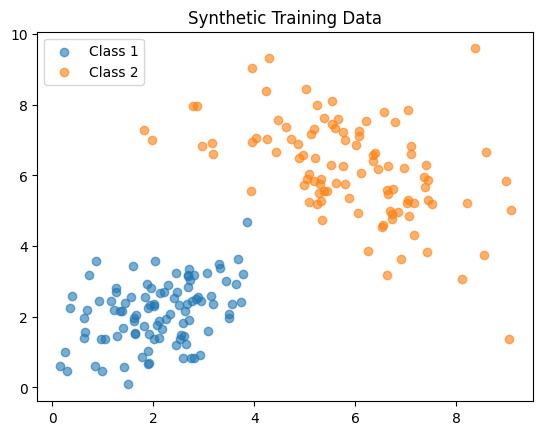

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Generate Synthetic Data (2 Classes)
np.random.seed(42)

# Class 1: Centered at (2,2) with some correlation
# Topic: Normal Distribution parameters (Slide 4)
mean1 = [2, 2]
cov1 = [[1, 0.5], [0.5, 1]]
X1 = np.random.multivariate_normal(mean1, cov1, 100)

# Class 2: Centered at (6,6) with different variance
mean2 = [6, 6]
cov2 = [[2, -0.8], [-0.8, 2]]
X2 = np.random.multivariate_normal(mean2, cov2, 100)

# Visualize
plt.scatter(X1[:,0], X1[:,1], alpha=0.6, label='Class 1')
plt.scatter(X2[:,0], X2[:,1], alpha=0.6, label='Class 2')
plt.legend()
plt.title("Synthetic Training Data")
plt.show()

In [12]:
def calculate_parameters(X):
    """
    Calculate the Mean vector and Covariance matrix for a dataset X.
    Topic: Appreciating Mean & Covariance (Slide 6 & 7)
    Args:
        X: numpy array of shape (N, 2)
    Returns:
        mean: numpy array of shape (2,)
        cov: numpy array of shape (2, 2)
    """
    # ---------------------------------------------------------
    # TODO: Use np.mean and np.cov to find parameters
    # Hint: np.cov expects rows as variables, so transpose X!
    
    mean = np.mean(X, axis=0)
    cov = np.cov(X.T)
    
    # ---------------------------------------------------------
    return mean, cov

# Compute parameters for both classes
mean1_est, cov1_est = calculate_parameters(X1)
mean2_est, cov2_est = calculate_parameters(X2)

print(f"Class 1 Mean: {mean1_est}")
print(f"Class 2 Mean: {mean2_est}")

Class 1 Mean: [2.08307042 2.11709274]
Class 2 Mean: [5.88193945 6.18543133]


In [13]:
def predict_bayes(point, m1, c1, m2, c2, prior1=0.5, prior2=0.5):
    """
    Classify a new point using Bayes Rule.
    Topic: Bayesian Decision Rule (Slide 10)
    
    Rule: Choose Class 1 if P(x|C1)*P(C1) > P(x|C2)*P(C2)
    
    Args:
        point: [x, y] coordinate
        m1, c1: Parameters for Class 1
        m2, c2: Parameters for Class 2
        prior1, prior2: Prior probabilities
    Returns:
        Predicted class label (1 or 2)
    """
    # ---------------------------------------------------------
    # TODO: Implement the decision rule
    # 1. Calculate Likelihood P(x|C) using multivariate_normal.pdf() (Slide 4)
    # 2. Calculate Posterior term (Likelihood * Prior)
    # 3. Compare and return label
    
    likelihood1 = multivariate_normal.pdf(point, mean=m1, cov=c1)
    likelihood2 = multivariate_normal.pdf(point, mean=m2, cov=c2)

    
    posterior1 = likelihood1 * prior1
    posterior2 = likelihood2 * prior2
    
    if posterior1 > posterior2:
        return 1
    else:
        return 2
    # ---------------------------------------------------------

# Test on a new point
test_point = [4, 4]
prediction = predict_bayes(test_point, mean1_est, cov1_est, mean2_est, cov2_est)
print(f"Point {test_point} is classified as Class: {prediction}")

Point [4, 4] is classified as Class: 1


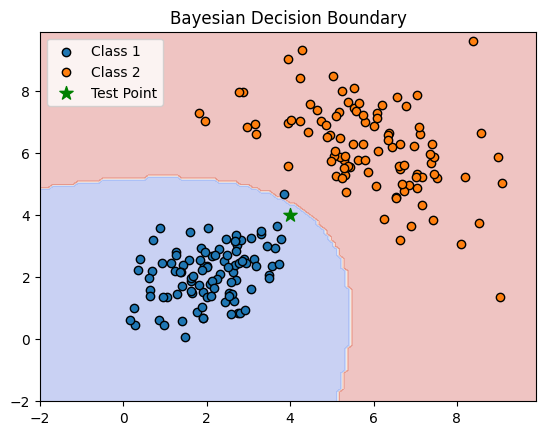

In [14]:
# Create a grid to visualize the Decision Boundary
# Topic: Optimal Bayesian Classifier (Slide 11)

# NOTE: This cell will only work after you implement predict_bayes above!

x_min, x_max = -2, 10
y_min, y_max = -2, 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

grid_points = np.c_[xx.ravel(), yy.ravel()]

try:
    Z = np.array([predict_bayes(pt, mean1_est, cov1_est, mean2_est, cov2_est) for pt in grid_points])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X1[:,0], X1[:,1], label='Class 1', edgecolors='k')
    plt.scatter(X2[:,0], X2[:,1], label='Class 2', edgecolors='k')
    plt.scatter(test_point[0], test_point[1], c='green', s=100, label='Test Point', marker='*')
    plt.title("Bayesian Decision Boundary")
    plt.legend()
    plt.show()
except Exception as e:
    print(f"Visualization failed. Did you implement predict_bayes yet? Error: {e}")